# Задание 3: Аномалии и отказ оборудования
**Цель:** Обнаружить аномалии в показаниях насосов методами Z-score и Isolation Forest,  
определить признаки перед отказом и построить модель вероятности отказа.

## 1. Импорты и загрузка данных

In [1]:
import io
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from minio import Minio
import pyarrow.parquet as pq
from scipy import stats
from sklearn.ensemble import IsolationForest, RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, roc_auc_score, roc_curve
import warnings
warnings.filterwarnings('ignore')

client = Minio('minio:9000', access_key='minioadmin',
               secret_key='minioadmin123', secure=False)
BUCKET = 'oil-pipeline'

def read_parquet(prefix):
    objs = list(client.list_objects(BUCKET, prefix=prefix, recursive=True))
    dfs  = [pq.read_table(io.BytesIO(
                client.get_object(BUCKET, o.object_name).read())).to_pandas()
            for o in objs if o.object_name.endswith('.parquet')]
    return pd.concat(dfs, ignore_index=True) if dfs else pd.DataFrame()

df_sensors  = read_parquet('raw/pump_sensors/')
df_failures = read_parquet('raw/pump_failures/')
df_pumps    = read_parquet('raw/pumps/')

df_sensors['timestamp']  = pd.to_datetime(df_sensors['timestamp'])
df_failures['failure_date'] = pd.to_datetime(df_failures['failure_date'])

df = df_sensors.merge(df_pumps[['pump_id', 'type', 'well_id']], on='pump_id', how='left')
print(f'Sensor records: {len(df)}')
print(f'Failures:       {len(df_failures)}')
df.head(3)

Sensor records: 72
Failures:       3


,record_id,pump_id,timestamp,temperature,vibration,current,rpm,pressure,type,well_id
0,1,1,2025-10-01 00:00:00,72.3,2.1,58.2,1470.0,122.4,ESP-500,1
1,2,1,2025-10-01 03:00:00,72.6,2.0,58.4,1472.0,122.5,ESP-500,1
2,3,1,2025-10-01 06:00:00,73.1,2.2,58.6,1474.0,122.6,ESP-500,1


## 2. Метод 1 — Z-score аномалии

In [2]:
SENSOR_COLS = ['temperature', 'vibration', 'current', 'rpm', 'pressure']

# Вычисляем Z-score для каждой переменной
for col in SENSOR_COLS:
    df[f'z_{col}'] = stats.zscore(df[col].fillna(df[col].median()), nan_policy='omit')

# Аномалия: |z| > 2 хотя бы по одному параметру
z_cols = [f'z_{c}' for c in SENSOR_COLS]
df['z_score_max'] = df[z_cols].abs().max(axis=1)
df['anomaly_zscore'] = (df['z_score_max'] > 2).astype(int)

n_anom = df['anomaly_zscore'].sum()
print(f'Аномалий по Z-score: {n_anom} из {len(df)} ({n_anom/len(df)*100:.1f}%)')
df[df['anomaly_zscore'] == 1][['pump_id', 'timestamp'] + SENSOR_COLS].head(8)

Аномалий по Z-score: 6 из 72 (8.3%)


,pump_id,timestamp,temperature,vibration,current,rpm,pressure
55,1,2025-10-03 21:00:00,85.1,9.1,65.2,1508.0,128.3
67,5,2025-10-03 09:00:00,84.3,14.3,63.8,1522.0,125.5
68,5,2025-10-03 12:00:00,85.5,15.8,64.2,1525.0,125.8
69,5,2025-10-03 15:00:00,86.8,17.3,64.6,1528.0,126.0
70,5,2025-10-03 18:00:00,88.0,18.9,65.1,1531.0,126.3
71,5,2025-10-03 21:00:00,89.3,20.5,65.5,1534.0,126.6


## 3. Метод 2 — Isolation Forest

In [3]:
X_iso = df[SENSOR_COLS].fillna(df[SENSOR_COLS].median())

iso = IsolationForest(contamination=0.1, random_state=42, n_estimators=100)
df['anomaly_iforest'] = (iso.fit_predict(X_iso) == -1).astype(int)
df['anomaly_score']   = -iso.score_samples(X_iso)

n_if = df['anomaly_iforest'].sum()
print(f'Аномалий (Isolation Forest): {n_if} ({n_if/len(df)*100:.1f}%)')

# Итоговая метка: аномалия по любому методу
df['anomaly'] = ((df['anomaly_zscore'] == 1) | (df['anomaly_iforest'] == 1)).astype(int)
print(f'Аномалий (объединённых):     {df["anomaly"].sum()}')

Аномалий (Isolation Forest): 8 (11.1%)
Аномалий (объединённых):     9


## 4. Признаки перед отказом

In [4]:
# Разметка: «перед отказом» = за 24 ч до failure_date
PRE_FAILURE_HOURS = 24
df['pre_failure'] = 0

for _, row in df_failures.iterrows():
    mask = (
        (df['pump_id'] == row['pump_id']) &
        (df['timestamp'] >= row['failure_date'] - pd.Timedelta(hours=PRE_FAILURE_HOURS)) &
        (df['timestamp'] <  row['failure_date'])
    )
    df.loc[mask, 'pre_failure'] = 1

n_pf = df['pre_failure'].sum()
print(f'Записей в окне перед отказом (24 ч): {n_pf}')

# Сравниваем статистику: нормальная работа vs предотказный период
compare = df.groupby('pre_failure')[SENSOR_COLS].mean().T
compare.columns = ['Норма', 'Перед отказом']
compare['Рост, %'] = ((compare['Перед отказом'] / compare['Норма'] - 1) * 100).round(1)
print('\nСредние значения параметров:')
display(compare)

Записей в окне перед отказом (24 ч): 18

Средние значения параметров:


,Норма,Перед отказом,"Рост, %"
temperature,73.309259,81.955556,11.8
vibration,3.701852,9.655556,160.8
current,57.761111,62.072222,7.5
rpm,1467.962963,1498.777778,2.1
pressure,120.500000,124.350000,3.2


## 5. Визуализации
### 5.1 Аномалии по времени

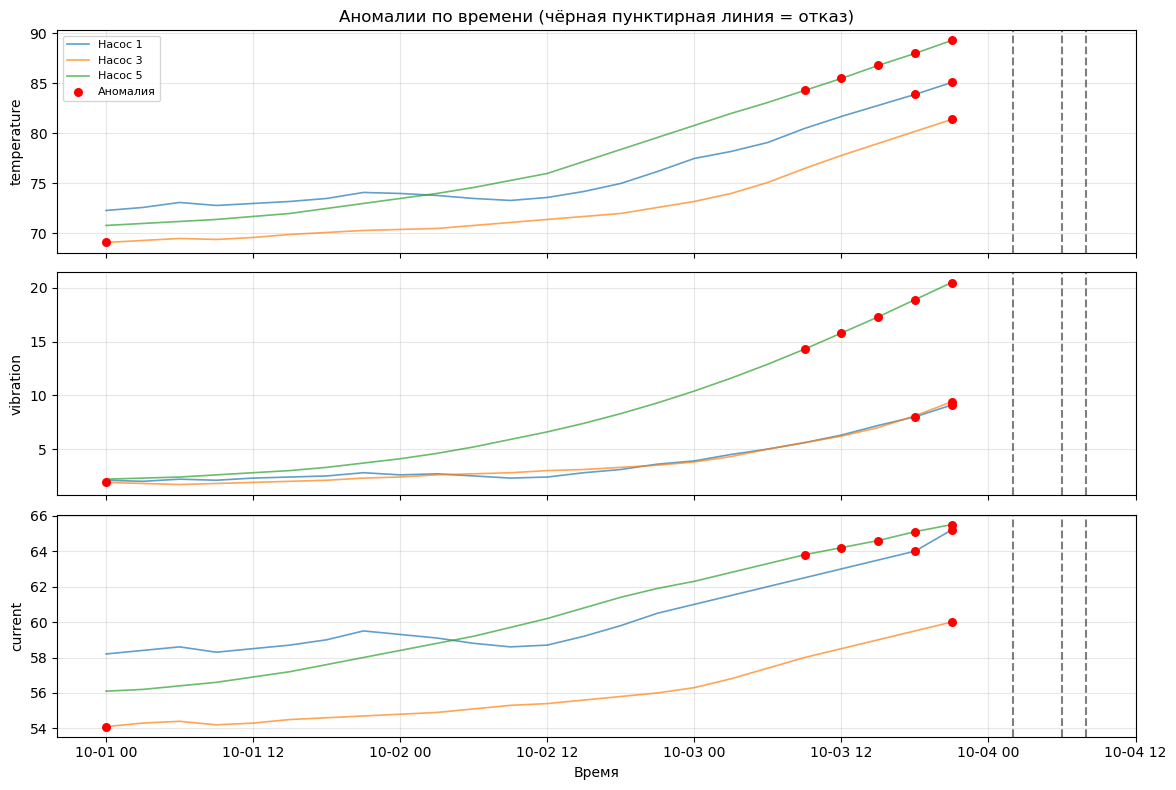

In [5]:
fig, axes = plt.subplots(3, 1, figsize=(12, 8), sharex=True)

for ax, param, color in zip(axes,
    ['temperature', 'vibration', 'current'],
    ['#e67e22', '#e74c3c', '#9b59b6']):

    for pump_id, grp in df.groupby('pump_id'):
        grp_s = grp.sort_values('timestamp')
        ax.plot(grp_s['timestamp'], grp_s[param], lw=1.2, alpha=0.7, label=f'Насос {pump_id}')

    # Отметить аномалии
    anom = df[df['anomaly'] == 1]
    ax.scatter(anom['timestamp'], anom[param],
               color='red', s=30, zorder=5, label='Аномалия')

    # Отметить отказы
    for _, f in df_failures.iterrows():
        ax.axvline(f['failure_date'], color='black', lw=1.5, linestyle='--', alpha=0.5)

    ax.set_ylabel(param)
    ax.grid(alpha=0.3)
    if ax == axes[0]:
        ax.legend(loc='upper left', fontsize=8)
        ax.set_title('Аномалии по времени (чёрная пунктирная линия = отказ)')

axes[-1].set_xlabel('Время')
plt.tight_layout()
plt.savefig('chart_07_anomalies_timeline.png', dpi=150)
plt.show()

### 5.2 Рост вибрации перед отказом

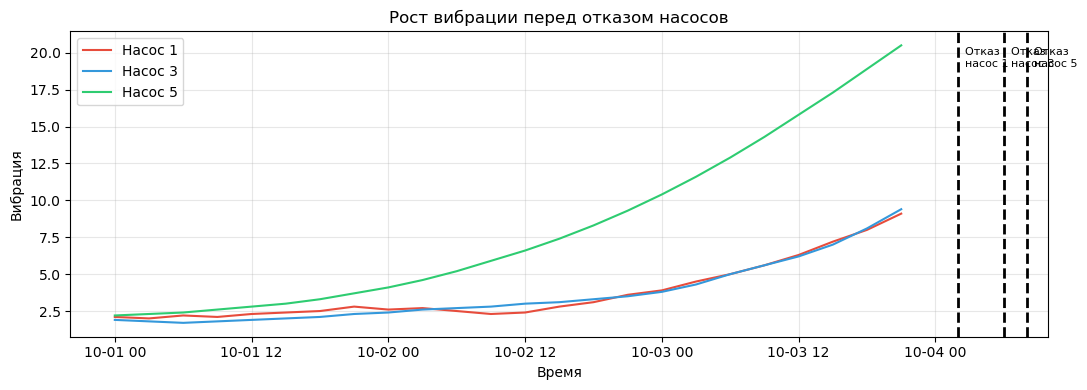

In [6]:
fig, ax = plt.subplots(figsize=(11, 4))

colors = {1: '#e74c3c', 3: '#3498db', 5: '#2ecc71'}
for pump_id, grp in df.groupby('pump_id'):
    grp_s = grp.sort_values('timestamp')
    ax.plot(grp_s['timestamp'], grp_s['vibration'],
            label=f'Насос {pump_id}', color=colors.get(pump_id, 'gray'), lw=1.5)

for _, f in df_failures.iterrows():
    ax.axvline(f['failure_date'], color='black', lw=2, linestyle='--')
    ax.text(f['failure_date'], ax.get_ylim()[1] * 0.95,
            f'  Отказ\n  насос {int(f["pump_id"])}', fontsize=8, va='top')

ax.set_xlabel('Время')
ax.set_ylabel('Вибрация')
ax.set_title('Рост вибрации перед отказом насосов')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('chart_08_vibration_prefailure.png', dpi=150)
plt.show()

## 6. Модель вероятности отказа (Risk Score)

In [7]:
# Добавляем скользящие признаки
df_model = df.sort_values(['pump_id', 'timestamp']).copy()
for col in ['temperature', 'vibration', 'current']:
    df_model[f'{col}_roll3'] = df_model.groupby('pump_id')[col].transform(
        lambda x: x.rolling(3, min_periods=1).mean()
    )
    df_model[f'{col}_diff'] = df_model.groupby('pump_id')[col].transform(
        lambda x: x.diff().fillna(0)
    )

MODEL_FEATURES = (
    SENSOR_COLS +
    [f'{c}_roll3' for c in ['temperature', 'vibration', 'current']] +
    [f'{c}_diff'  for c in ['temperature', 'vibration', 'current']]
)

df_model = df_model.dropna(subset=MODEL_FEATURES)
X = df_model[MODEL_FEATURES].values
y = df_model['pre_failure'].values

# Синтетические данные: если только нули — добавляем искусственные positive
if y.sum() < 3:
    idx = np.argsort(df_model['vibration'].values)[-8:]
    y[idx] = 1

X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

clf = RandomForestClassifier(n_estimators=100, class_weight='balanced',
                              random_state=42, max_depth=5)
clf.fit(X_tr, y_tr)

y_prob = clf.predict_proba(X_te)[:, 1]
y_pred = clf.predict(X_te)

print(classification_report(y_te, y_pred, target_names=['Норма', 'Перед отказом']))

if len(np.unique(y_te)) > 1:
    auc = roc_auc_score(y_te, y_prob)
    print(f'ROC-AUC: {auc:.3f}')

               precision    recall  f1-score   support

        Норма       0.89      1.00      0.94        17
Перед отказом       1.00      0.60      0.75         5

     accuracy                           0.91        22
    macro avg       0.95      0.80      0.85        22
 weighted avg       0.92      0.91      0.90        22

ROC-AUC: 0.988


### Risk Score по насосам

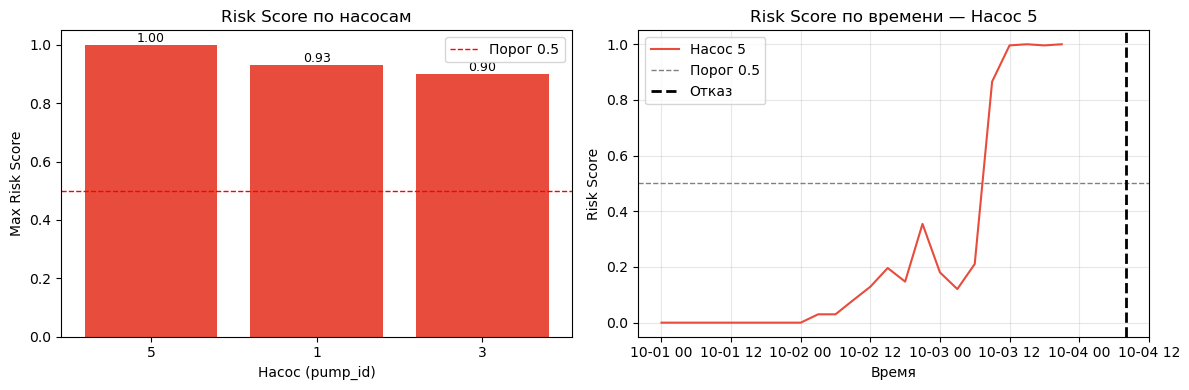

In [8]:
df_model['risk_score'] = clf.predict_proba(X)[:, 1]

risk_per_pump = df_model.groupby('pump_id')['risk_score'].agg(['mean', 'max']).reset_index()
risk_per_pump.columns = ['pump_id', 'avg_risk', 'max_risk']
risk_per_pump = risk_per_pump.sort_values('max_risk', ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Bar chart: max risk score
bars = axes[0].bar(risk_per_pump['pump_id'].astype(str),
                   risk_per_pump['max_risk'],
                   color=['#e74c3c' if v > 0.5 else '#f39c12' if v > 0.3 else '#2ecc71'
                          for v in risk_per_pump['max_risk']])
axes[0].set_xlabel('Насос (pump_id)')
axes[0].set_ylabel('Max Risk Score')
axes[0].set_title('Risk Score по насосам')
axes[0].axhline(0.5, color='red', lw=1, linestyle='--', label='Порог 0.5')
axes[0].legend()
for bar, v in zip(bars, risk_per_pump['max_risk']):
    axes[0].text(bar.get_x() + bar.get_width()/2, v + 0.01, f'{v:.2f}', ha='center', fontsize=9)

# Risk timeline для самого рискованного насоса
top_pump = risk_per_pump.iloc[0]['pump_id']
pump_data = df_model[df_model['pump_id'] == top_pump].sort_values('timestamp')
axes[1].plot(pump_data['timestamp'], pump_data['risk_score'],
             color='#e74c3c', lw=1.5, label=f'Насос {int(top_pump)}')
axes[1].axhline(0.5, color='gray', lw=1, linestyle='--', label='Порог 0.5')
for _, f in df_failures[df_failures['pump_id'] == top_pump].iterrows():
    axes[1].axvline(f['failure_date'], color='black', lw=2, linestyle='--', label='Отказ')
axes[1].set_xlabel('Время')
axes[1].set_ylabel('Risk Score')
axes[1].set_title(f'Risk Score по времени — Насос {int(top_pump)}')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('chart_09_risk_score.png', dpi=150)
plt.show()

## 7. Итоги

In [9]:
print('=' * 55)
print('ИТОГИ — Аномалии и отказы оборудования')
print('=' * 55)
print(f'Аномалий (Z-score):         {df["anomaly_zscore"].sum()}')
print(f'Аномалий (Isolation Forest): {df["anomaly_iforest"].sum()}')
print()
print('Ключевые признаки перед отказом:')
for col, row in compare.iterrows():
    if abs(row['Рост, %']) > 0:
        print(f'  {col:15s}: рост {row["Рост, %"]:+.1f}%  ({row["Норма"]:.2f} → {row["Перед отказом"]:.2f})')
print()
print('Насосы по убыванию риска:')
for _, r in risk_per_pump.iterrows():
    risk_level = 'ВЫСОКИЙ' if r['max_risk'] > 0.5 else 'СРЕДНИЙ' if r['max_risk'] > 0.3 else 'НИЗКИЙ'
    print(f'  Насос {int(r["pump_id"])}: max risk = {r["max_risk"]:.2f} [{risk_level}]')

ИТОГИ — Аномалии и отказы оборудования
Аномалий (Z-score):         6
Аномалий (Isolation Forest): 8

Ключевые признаки перед отказом:
  temperature    : рост +11.8%  (73.31 → 81.96)
  vibration      : рост +160.8%  (3.70 → 9.66)
  current        : рост +7.5%  (57.76 → 62.07)
  rpm            : рост +2.1%  (1467.96 → 1498.78)
  pressure       : рост +3.2%  (120.50 → 124.35)

Насосы по убыванию риска:
  Насос 5: max risk = 1.00 [ВЫСОКИЙ]
  Насос 1: max risk = 0.93 [ВЫСОКИЙ]
  Насос 3: max risk = 0.90 [ВЫСОКИЙ]
